In [1]:
# Import
import numpy as np
import random as rn
import casadi as ca
import os, json
from scipy.interpolate import splprep, splev
import importlib
import csv
from scipy.interpolate import interp1d
import time
import math

# Import Graphics
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as patches
from IPython.display import HTML
from matplotlib.patches import Polygon as PolyPatch, Wedge, FancyArrow

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
ADSE_MC_Result = {}
ADSE_MC_Result['n_success'] = []
ADSE_MC_Result['d_cost'] = {}
ADSE_MC_Result['a_cost'] = {}
ADSE_MC_Result['payoff'] = {}
ADSE_MC_Result['stopping_criteria'] = {}

num_batch = 50

for MC_iter in range(num_batch):
    with open('Monte_Carlo_Batch_' + str(MC_iter) + '_SEGame_Monte_Carlo_for_Section_VC.json', 'r') as json_file:
            result = json.load(json_file)

            ADSE_MC_Result['n_success'].append(result['n_success'])
            ADSE_MC_Result['d_cost'][str(MC_iter)] = result['d_cost']
            ADSE_MC_Result['a_cost'][str(MC_iter)] = result['a_cost']
            ADSE_MC_Result['payoff'][str(MC_iter)] = result['payoff']
            ADSE_MC_Result['stopping_criteria'][str(MC_iter)] = result['stopping_criteria']

In [3]:
# Exact initial and final values of defender cost

defender_cost_init_list = []
defender_cost_fin_list = []

for MC_iter in range(num_batch):
    for i in range(len(ADSE_MC_Result['d_cost'][str(MC_iter)])):
        defender_cost_init_list.append(ADSE_MC_Result['d_cost'][str(MC_iter)][str(i)][0])
        defender_cost_fin_list.append(ADSE_MC_Result['d_cost'][str(MC_iter)][str(i)][-1])

# Exact initial and final values of defender cost

attacker_cost_init_list = []
attacker_cost_fin_list = []

for MC_iter in range(num_batch):
    for i in range(len(ADSE_MC_Result['a_cost'][str(MC_iter)])):
        attacker_cost_init_list.append(ADSE_MC_Result['a_cost'][str(MC_iter)][str(i)][0])
        attacker_cost_fin_list.append(ADSE_MC_Result['a_cost'][str(MC_iter)][str(i)][-1])

73.9558605613186
-13.036992962823428
69.90008810700171
32.309538660969594


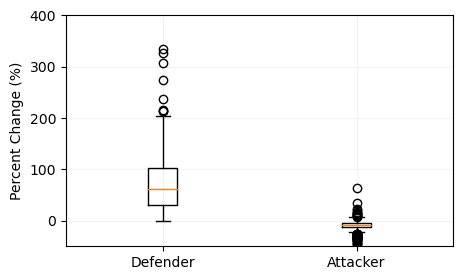

In [4]:
# Compute percent-decrease in defender and attacker cost

defender_cost_percent_decrease_list = []
attacker_cost_percent_decrease_list = []

for i in range(len(defender_cost_fin_list)):
    defender_cost_percent_decrease_list.append((defender_cost_fin_list[i] - defender_cost_init_list[i]) / defender_cost_init_list[i] * 10)

for i in range(len(attacker_cost_fin_list)):
    attacker_cost_percent_decrease_list.append((attacker_cost_fin_list[i] - attacker_cost_init_list[i]) / attacker_cost_init_list[i] * -100)

print(np.mean(defender_cost_percent_decrease_list))
print(np.mean(attacker_cost_percent_decrease_list))
print(np.std(defender_cost_percent_decrease_list))
print(np.std(attacker_cost_percent_decrease_list))

# Plot box-whisker plot of percent-decrease in defender and attacker cost
plt.figure(figsize=(5, 3))
plt.boxplot([np.abs(defender_cost_percent_decrease_list), attacker_cost_percent_decrease_list],
            labels=['Defender', 'Attacker'])
plt.grid(alpha=0.15) # Add grid with reduced opacity
plt.ylabel('Percent Change (%)')
plt.ylim(-50, 400)
plt.savefig('Cost_Percent_Decrease_Boxplot.png')

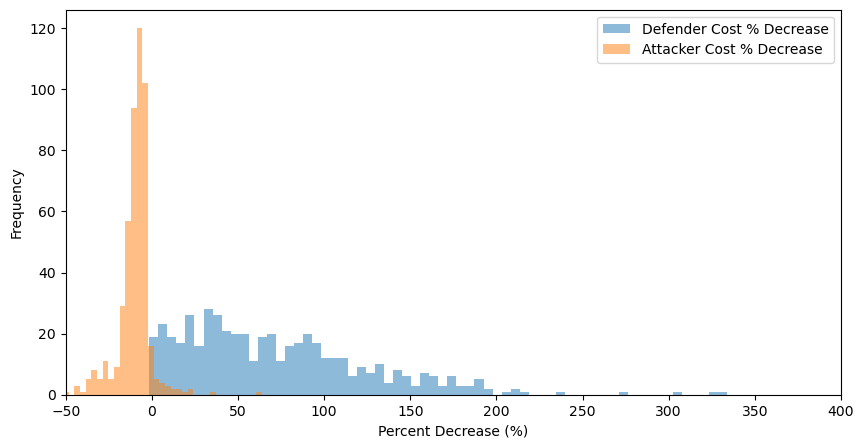

In [5]:
# Make histogram

fig = plt.figure(figsize=(10, 5))
plt.hist(defender_cost_percent_decrease_list, bins=200, alpha=0.5, label='Defender Cost % Decrease')
plt.hist(attacker_cost_percent_decrease_list, bins=200, alpha=0.5, label='Attacker Cost % Decrease')
plt.xlabel('Percent Decrease (%)')
plt.ylabel('Frequency')
plt.xlim(-50, 400)
plt.legend()
plt.savefig('Cost_Percent_Decrease_Histogram.png')

In [6]:
import numpy as np
from scipy import stats

def compute_mc_statistics(data: np.ndarray, label: str = "", confidence: float = 0.95):
    """
    Compute mean, std, and confidence interval for Monte Carlo simulation results.

    Args:
        data       : 1D array of MC trial results
        label      : name of the metric (for printing)
        confidence : confidence level (default 0.95 for 95% CI)

    Returns:
        dict with mean, std, ci_lower, ci_upper, margin
    """
    N    = len(data)
    mean = np.mean(data)
    std  = np.std(data, ddof=1)          # ddof=1 → sample std
    sem  = std / np.sqrt(N)              # standard error of the mean

    # Use t-distribution (works for any N; converges to z=1.96 for large N)
    t_crit = stats.t.ppf((1 + confidence) / 2, df=N - 1)
    margin = t_crit * sem

    ci_lower = mean - margin
    ci_upper = mean + margin

    if label:
        print(f"--- {label} (N={N}) ---")
        print(f"  Mean         : {mean:.4f}")
        print(f"  Std Dev      : {std:.4f}")
        print(f"  {int(confidence*100)}% CI       : [{ci_lower:.4f}, {ci_upper:.4f}]")
        print(f"  Margin (±)   : {margin:.4f}")
        print()

    return {
        "label"    : label,
        "N"        : N,
        "mean"     : mean,
        "std"      : std,
        "ci_lower" : ci_lower,
        "ci_upper" : ci_upper,
        "margin"   : margin,
    }


def compute_percent_improvement(initial: np.ndarray, optimized: np.ndarray,
                                 label: str = "", confidence: float = 0.95):
    """
    Compute % improvement per trial, then report mean, std, and CI on those values.

    % improvement = (J^0 - J^*) / J^0 * 100
    Positive value means J decreased (improvement).

    Args:
        initial   : 1D array of J^0 values across MC trials
        optimized : 1D array of J^* values across MC trials
        label     : metric name
        confidence: confidence level
    """
    # pct_change = (initial - optimized) / np.abs(initial) * 100
    # Filter out near-zero initial values before computing % change
    threshold = 1e-3  # adjust based on your scale
    valid = np.abs(initial) > threshold
    pct_change = (optimized[valid] - initial[valid]) / np.abs(initial[valid]) * 100
    n_filtered = np.sum(~valid)
    if n_filtered > 0:
        print(f"  [{label}] Filtered {n_filtered}/{len(initial)} trials with |J^0| < {threshold}")
    return compute_mc_statistics(pct_change, label=f"% Improvement in {label}", confidence=confidence)

def compute_absolute_improvement(initial: np.ndarray, optimized: np.ndarray,
                                  label: str = "", confidence: float = 0.95):
    """
    Compute absolute change per trial: delta = optimized - initial
    Positive = increase, Negative = decrease.
    """
    delta = optimized - initial
    return compute_mc_statistics(delta, label=f"Absolute Change in {label}", confidence=confidence)

def summarize_table(results: list[dict]):
    """Print a summary table of all metrics."""
    print("=" * 70)
    print(f"{'Metric':<25} {'Mean':>10} {'Std Dev':>10} {'CI Lower':>10} {'CI Upper':>10}")
    print("=" * 70)
    for r in results:
        print(f"{r['label']:<25} {r['mean']:>10.4f} {r['std']:>10.4f} "
              f"{r['ci_lower']:>10.4f} {r['ci_upper']:>10.4f}")
    print("=" * 70)



# --- Raw statistics ---
r1 = compute_mc_statistics(attacker_cost_fin_list,   label="J_A  (Initial)")
r2 = compute_mc_statistics(attacker_cost_init_list, label="J_A  (LNE)")
r3 = compute_mc_statistics(defender_cost_init_list,   label="J_D  (Initial)")
r4 = compute_mc_statistics(defender_cost_fin_list, label="J_D  (LNE)")

summarize_table([r1, r2, r3, r4])

# --- % Improvement statistics ---
p1 = compute_absolute_improvement(np.array(attacker_cost_fin_list), np.array(attacker_cost_init_list), label="J_A")
p2 = compute_absolute_improvement(np.array(defender_cost_init_list), np.array(defender_cost_fin_list), label="J_D")

summarize_table([p1, p2])

--- J_A  (Initial) (N=500) ---
  Mean         : 0.4017
  Std Dev      : 0.2138
  95% CI       : [0.3829, 0.4205]
  Margin (±)   : 0.0188

--- J_A  (LNE) (N=500) ---
  Mean         : 0.3613
  Std Dev      : 0.1918
  95% CI       : [0.3445, 0.3782]
  Margin (±)   : 0.0169

--- J_D  (Initial) (N=500) ---
  Mean         : 0.1028
  Std Dev      : 0.1292
  95% CI       : [0.0915, 0.1142]
  Margin (±)   : 0.0113

--- J_D  (LNE) (N=500) ---
  Mean         : 0.4192
  Std Dev      : 0.2282
  95% CI       : [0.3991, 0.4392]
  Margin (±)   : 0.0201

Metric                          Mean    Std Dev   CI Lower   CI Upper
J_A  (Initial)                0.4017     0.2138     0.3829     0.4205
J_A  (LNE)                    0.3613     0.1918     0.3445     0.3782
J_D  (Initial)                0.1028     0.1292     0.0915     0.1142
J_D  (LNE)                    0.4192     0.2282     0.3991     0.4392
--- Absolute Change in J_A (N=500) ---
  Mean         : -0.0403
  Std Dev      : 0.0683
  95% CI       : [

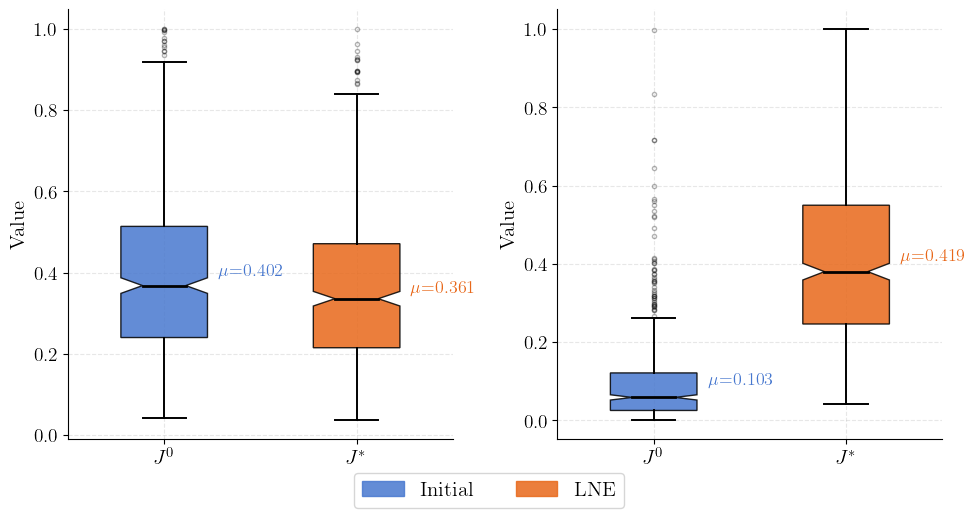

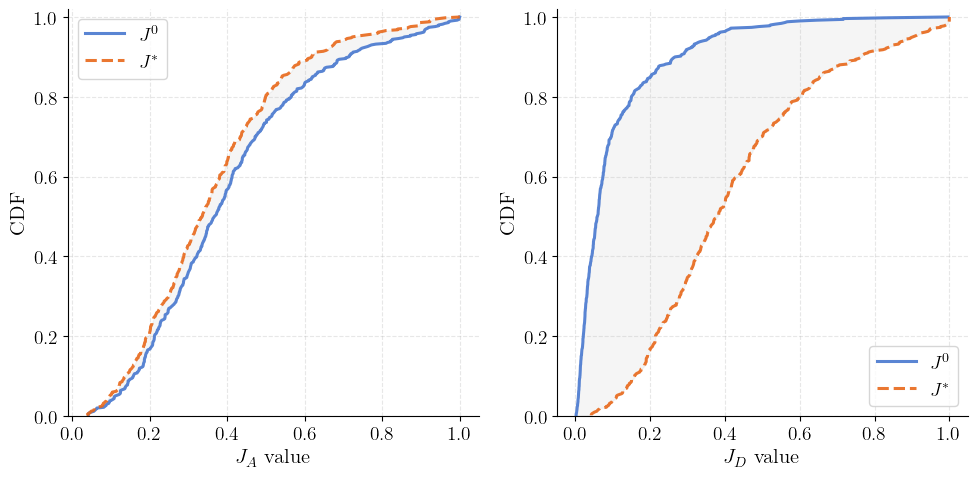

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import matplotlib as mpl
mpl.rcParams['font.size'] = 14
mpl.rcParams['text.usetex'] = True


# ── Replace these with your actual data arrays ────────────────────────────────
# J_A_initial   = attacker_cost_init_list
# J_A_optimized = attacker_cost_fin_list
# J_D_initial   = defender_cost_init_list
# J_D_optimized = defender_cost_fin_list

# ── Plot settings ─────────────────────────────────────────────────────────────
COLOR_INIT = "#4878CF"   # blue  — Initial
COLOR_LNE  = "#E8681A"   # orange — LNE
ALPHA      = 0.85
FONTSIZE   = 15

plt.rcParams.update({
    "font.family"      : "serif",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "grid.linestyle"   : "--",
})

J_A_initial = attacker_cost_fin_list
J_A_optimized = attacker_cost_init_list
J_D_initial = defender_cost_init_list
J_D_optimized = defender_cost_fin_list

# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Box Plot
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# fig.suptitle("Monte Carlo Results: Initial vs. LNE Placement (N=500)",
#              fontsize=FONTSIZE + 1, fontweight="bold", y=1.01)

datasets = [
    (axes[0], J_A_initial, J_A_optimized, r"$J_A$", "Attacker"),
    (axes[1], J_D_initial, J_D_optimized, r"$J_D$", "Defender"),
]

for ax, init, lne, metric, subtitle in datasets:
    bp = ax.boxplot(
        [init, lne],
        patch_artist=True,
        notch=True,               # notch shows 95% CI on median
        widths=0.45,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(linewidth=1.4),
        capprops=dict(linewidth=1.4),
        flierprops=dict(marker="o", markersize=3, alpha=0.3),
    )
    colors = [COLOR_INIT, COLOR_LNE]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(ALPHA)

    ax.set_xticks([1, 2])
    ax.set_xticklabels([r"$J^0$", r"$J^*$"], fontsize=FONTSIZE)
    # ax.set_title(f"{metric}  —  {subtitle}", fontsize=FONTSIZE, pad=8)
    ax.set_ylabel("Value", fontsize=FONTSIZE)
    ax.tick_params(axis="y", labelsize=FONTSIZE - 1)

    # annotate means
    for x, data, color in zip([1, 2], [init, lne], colors):
        ax.annotate(f"$\\mu$={np.mean(data):.3f}",
                    xy=(x, np.mean(data)),
                    xytext=(x + 0.28, np.mean(data)),
                    fontsize=FONTSIZE - 2, color=color, fontweight="bold",
                    va="center")

patch_init = mpatches.Patch(color=COLOR_INIT, alpha=ALPHA, label="Initial")
patch_lne  = mpatches.Patch(color=COLOR_LNE,  alpha=ALPHA, label="LNE")
fig.legend(handles=[patch_init, patch_lne], loc="lower center",
           ncol=2, fontsize=FONTSIZE, bbox_to_anchor=(0.5, -0.06))

plt.tight_layout()
plt.savefig("boxplot_JA_JD.pdf", bbox_inches="tight", dpi=300)
plt.savefig("boxplot_JA_JD.png", bbox_inches="tight", dpi=300)

# ═════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — CDF Plot
# ═════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# fig.suptitle("CDF of Monte Carlo Results: Initial vs. LNE Placement (N=500)",
            #  fontsize=FONTSIZE + 1, fontweight="bold", y=1.01)

datasets_cdf = [
    (axes[0], J_A_initial, J_A_optimized, r"$J_A$", "Attacker"),
    (axes[1], J_D_initial, J_D_optimized, r"$J_D$", "Defender"),
]

for ax, init, lne, metric, subtitle in datasets_cdf:
    for data, color, label, ls in [
        (init, COLOR_INIT, r"$J^0$",  "-"),
        (lne,  COLOR_LNE,  r"$J^*$",      "--"),
    ]:
        sorted_data = np.sort(data)
        cdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
        ax.plot(sorted_data, cdf, color=color, linewidth=2.2,
                linestyle=ls, label=label, alpha=0.9)

        # shade between initial and LNE
    init_sorted = np.sort(init)
    lne_sorted  = np.sort(lne)
    # interpolate onto common x grid for shading
    x_min = min(init_sorted[0], lne_sorted[0])
    x_max = max(init_sorted[-1], lne_sorted[-1])
    x_grid = np.linspace(x_min, x_max, 500)
    cdf_init_interp = np.interp(x_grid, init_sorted,
                                np.arange(1, len(init_sorted)+1)/len(init_sorted))
    cdf_lne_interp  = np.interp(x_grid, lne_sorted,
                                np.arange(1, len(lne_sorted)+1)/len(lne_sorted))
    ax.fill_betweenx(np.linspace(0, 1, 500),
                     np.interp(np.linspace(0,1,500), cdf_init_interp, x_grid),
                     np.interp(np.linspace(0,1,500), cdf_lne_interp,  x_grid),
                     alpha=0.08, color="gray")

    ax.set_xlabel(f"{metric} value", fontsize=FONTSIZE)
    ax.set_ylabel("CDF", fontsize=FONTSIZE)
    # ax.set_title(f"{metric}  —  {subtitle}", fontsize=FONTSIZE, pad=8)
    ax.set_ylim(0, 1.02)
    ax.tick_params(labelsize=FONTSIZE - 1)
    ax.legend(fontsize=FONTSIZE - 1)

plt.tight_layout()
plt.savefig("cdf_JA_JD.pdf", bbox_inches="tight", dpi=300)
plt.savefig("cdf_JA_JD.png", bbox_inches="tight", dpi=300)

In [ ]:
# Check if last K iterations show oscillating (non-decaying) delta_J
K = 6  # last 6 iterations

threshold = 0.1  # ratio threshold to flag limit cycle

limit_cycle_count = 0

for MC_iter in range(num_batch):
    for i in range(len(ADSE_MC_Result['d_cost'][str(MC_iter)])):
        delta_J_tail = ADSE_MC_Result['d_cost'][str(MC_iter)][str(i)][-K:]
        # print(delta_J_tail)

        
        # Limit cycle if tail variance is high relative to mean
        # i.e. still oscillating rather than plateauing
        ratio = np.std(delta_J_tail) / (np.mean(delta_J_tail) + 1e-10)
        is_limit_cycle = ratio > threshold  # e.g. 0.3
        if is_limit_cycle == True:
            limit_cycle_count += 1

print(limit_cycle_count)

16
